<a href="https://colab.research.google.com/github/alimoorreza/CS181-fall26-notes/blob/main/cs181_linear_filtering_cross_correlation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CS181: Day02
## Linear filtering

#### CS181: Computer Vision, Fall 2026

Wednesday, August 27th, 2026

📆 [Course Schedule](https://analytics.drake.edu/~reza/teaching/cs181_fall26/cs181_schedule.html) | 📜 [Syllabus](https://analytics.drake.edu/~reza/teaching/cs181_fall26/cs181_syllabus_fall26.pdf)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#**Getting up to speed with Pillow**
> PIL: Python Imaging Library
>> [Pillow concepts](https://pillow.readthedocs.io/en/stable/handbook/concepts.html)

>> [Pillow tutorial](https://pillow.readthedocs.io/en/stable/handbook/tutorial.html)

> Python does not have native support for image processing so we encourage students to make use of the

> Pillow Library, supported at https://colab.research.google.com/. You could also install this library in your machines. If you wish to install it into your own system, simply do pip install Pillow.

> Below we show some sample code that loads a grayscale image, checks some of its properties, and creates a new
color image based on its pixel values.

Grayscale image
Size info (from numpy array): (height=361, width=355)
Size info (from PIL): (width=355, height=361)


Text(0.5, 1.0, 'taj mahal noisy')

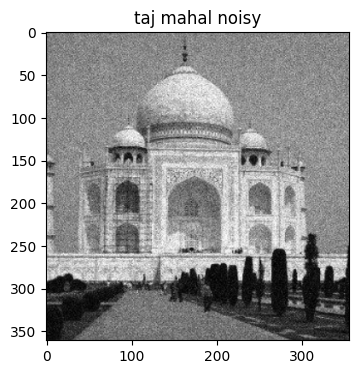

In [21]:
from PIL import Image, ImageOps
import numpy as np
import matplotlib.pyplot as plt

# load the image
img_pil         = Image.open('/content/drive/MyDrive/cs181_fall26/module_1_low_level_vision/images/tajmahal_noisy.png')
img_pil_array   = np.asarray(img_pil)
if len(img_pil.size) == 2:
    print(f"Grayscale image")


# print the size of the image
print(f"Size info (from numpy array): (height={img_pil_array.shape[0]}, width={img_pil_array.shape[1]})")
print(f"Size info (from PIL): (width={img_pil.width}, height={img_pil.height})")


# plot the image
plt.figure( figsize=(4,4) )           # figure size (4 inch, 4 inch)
plt.imshow(img_pil, cmap='gray')
plt.title("taj mahal noisy")

#**Modifying the pixel value at a random location inside the image**

> Chose any arbitrary new intensity of a pixel

> Change the pixel's old intensity value specified by its (x,y) coordinate

> Use the following two PIL.Image functions:

> `img_pil.getpixel()`

>> It takes as arguments a pixel location specified by `(x, y)`

> `img_pil.putpixel()`

>> It takes two arguments: the first is a pixel location specified by `(x, y)`, and the second is the new intensity value specified by an integer value `new_intensity`.

Pixel value is 20
New pixel value is 200


Text(0.5, 1.0, 'Taj Mahal: modified pixel')

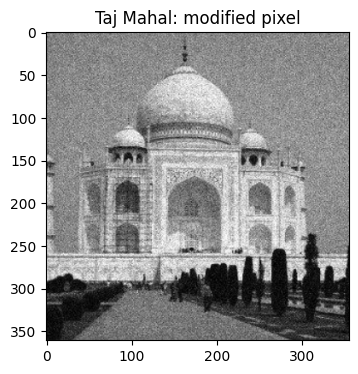

In [23]:
new_intensity_value = 200

x = 10
y = 10

# Reading a pixel: pixels are accessible via (x,y) tuples
print(f"Pixel's old intensity={ img_pil.getpixel( (x, y) )}")


# Writing a pixel: pixels can be modified by specifying the coordinate and RGB value
img_pil.putpixel((x, y), new_intensity_value)
print(f"Pixel's new intensity={ img_pil.getpixel( (x, y) )}")


# plot the image to see the change
plt.figure(figsize=(4,4))                     # figure size (4 inch, 4 inch)
plt.imshow(np.asarray(img_pil), cmap='gray')
plt.title('Taj Mahal: modified pixel')

#**Modifying the pixel intensities/values within a fixed square**
> Make a black square inside any location of the image

> Chose any arbitrary size of your square

Grayscale image size: (361, 355)
image size: (361, 355)


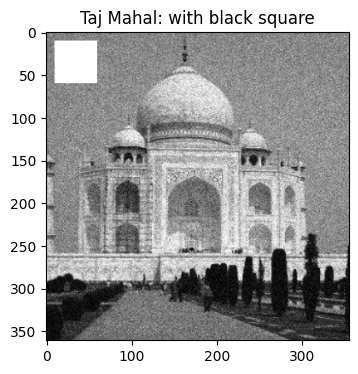

In [26]:
# read a fresh copy of the image so that you can over write any mistakes
img_pil         = Image.open('/content/drive/MyDrive/cs181_fall26/module_1_low_level_vision/images/tajmahal_noisy.png')
img_pil_array   = np.asarray(img_pil)

if (len(img_pil_array.shape) == 2):
  print("Grayscale image size:", img_pil_array.shape)
elif (len(img_pil_array.shape) > 2):
  print("Color image size:", img_pil_array.shape)


new_intensity_value = 255
sq_size             = 50
st_offset           = 10
for x in range(st_offset, st_offset + sq_size):
  for y in range(st_offset, st_offset + sq_size):
    # writing a pixel: pixels can be modified by specifying the coordinate and RGB value
    img_pil.putpixel( (x, y), new_intensity_value)

# plot the image to see the change
plt.figure(figsize=(4,4))                     # figure size (4 inch, 4 inch)
plt.imshow(np.asarray(img_pil), cmap='gray')
plt.title('Taj Mahal: with black square')
print("image size:", img_pil_array.shape)

#**Group activity#1: Modifying the pixel values within a fixed rectangle**
> Now, let's tweak the code a bit to create a black rectangle (instead of a square) at any location within the image.

> Choose any size you like for your *rectangle* by defining the **rec_width** and **rec_height** variables.

In [ ]:
# Your code here
# ...
# ...
# ...

Grayscale image size: (361, 355)
image size: (361, 355)


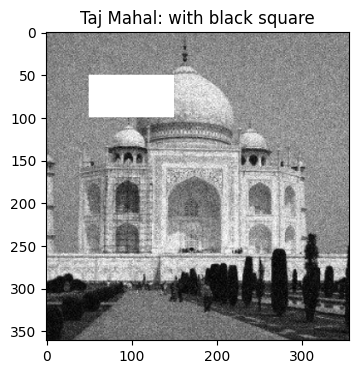

#**Changing the color of selected regions**
> Create an empty color image with three channels, i.e., (Red, Green, Blue). This image should have the same size as the input Taj Mahal image. All pixel values are initialized with zeros. Please note that a lower value signifies a darker color.

> Run through a nested for loop with the image width and image height that iterates through all the pixels of the original grayscale image.

>> For a pixel `(x, y)`, if it has a brighter intensity (i.e., a higher intensity value), put the intensity of that pixel into the Red channel while making the other two channels zero.

>> Otherwise, make the pixel grayscale with the same value for all three channels: `Red = old_grayscale_intensity`, `Green = old_grayscale_intensity`, `Blue = old_grayscale_intensity`.

Grayscale image size: (361, 355)


Text(0.5, 1.0, 'Taj Mahal: colored photo')

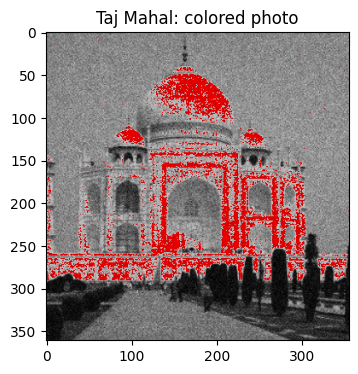

In [28]:
# create a new blank image the same size as the input
# provide 'RGB' attribute so that a color image is created
img_pil         = Image.open('/content/drive/MyDrive/cs181_fall26/module_1_low_level_vision/images/tajmahal_noisy.png')
if (len(img_pil_array.shape) == 2):
  print("Grayscale image size:", img_pil_array.shape)
elif (len(img_pil_array.shape) > 2):
  print("Color image size:", img_pil_array.shape)


# create a empty color image (all dark pixel values)
colorim_pil     = Image.new('RGB', (img_pil.width , img_pil.height), color = 0)
#img_pil_array   = np.asarray(colorim_pil)


# loop over the new color image and fill in brighter area (that was white before when we loaded) with red colors!
# basically we transformed the gray colored into a red colored one!
# new_red_intensity = 100
for x in range(colorim_pil.width):
    for y in range(colorim_pil.height):
        old_grayscale_intensity = img_pil.getpixel((x,y))
        #print(old_grayscale_intensity)

        if ( old_grayscale_intensity >= 200 ):
            colorim_pil.putpixel((x,y), (old_grayscale_intensity,0,0))
        else:
            colorim_pil.putpixel((x,y), (old_grayscale_intensity, old_grayscale_intensity, old_grayscale_intensity))


# plot the image to see the change
plt.figure(figsize=(4,4))                     # figure size (4 inch, 4 inch)
plt.imshow(np.asarray(colorim_pil ))
plt.title('Taj Mahal: colored photo')

#colorim.show()
#colorim.save('output.png')

#**Group activity #2: Change the color of the bush and tree regions to green**
> Start by making a new image with the same size as the ****'Taj Mahal'**** image.

> Then, change the bushes and tree regions in the picture to green pixels.


Grayscale image size: (361, 355)


Text(0.5, 1.0, 'Taj Mahal: colored photo')

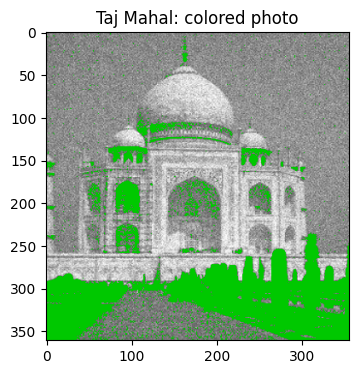

In [31]:
# Your code here
# ...
# ...
# ...

#**Adding text on top of the image at a random position**
You can utilize features such as the `ImageDraw.Draw(colorim_pil)` module and its `.text( , , )` method.

For the `.text()` method, you need to provide three arguments:

The `(text_x, text_y)` pixel or coordinate (as a tuple) where you want to draw the text.

The text you want to draw, e.g., `Taj Mahal`.

And finally, the color of the text, e.g., `blue`.

> Reference: [Image.Draw module for drawing shapes/text](https://pillow.readthedocs.io/en/stable/reference/ImageDraw.html#imagedraw-module)


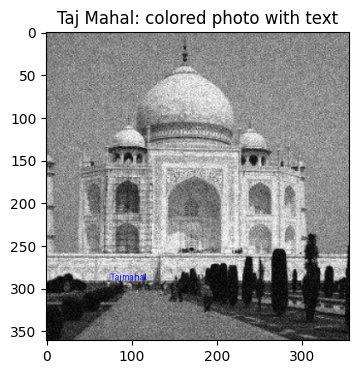

In [36]:
from PIL import ImageDraw
import random

img_pil         = Image.open('/content/drive/MyDrive/cs181_fall26/module_1_low_level_vision/images/tajmahal_noisy.png')
colorim_pil     = img_pil.convert("RGB")

# adding text on top of the color image at a random position

# initialize ImageDraw
img_pil_with_text = ImageDraw.Draw(colorim_pil)

# generate a random X-coordinate and a random Y-coordinate
text_x_coord = random.randint(0 , colorim_pil.width//2)
text_y_coord = random.randint(0 , colorim_pil.height)
img_pil_with_text.text( (text_x_coord, text_y_coord), 'Tajmahal', (0, 0, 255))


# plot the image to see the change
plt.figure(figsize=(4,4))                     # figure size (4 inch, 4 inch)
plt.imshow(np.asarray(colorim_pil))
plt.title('Taj Mahal: colored photo with text')
colorim_pil.save('output_with_text.png')

#**Drawing blue rectangle at a random location**

> Make a blue rectangle inside any random location of the image

> Chose any arbitrary size of your rectangle

You can utilize features such as
>> `ImageDraw.Draw(colorim_pil)` module and its
>> `.rectangle([top_left, bottom_right], outline="blue")` method.


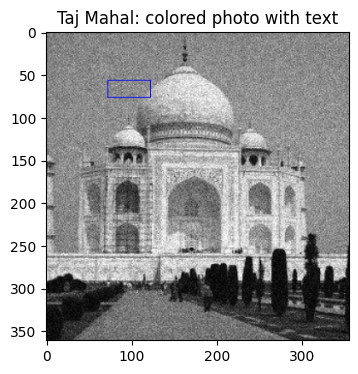

In [ ]:
from PIL import ImageDraw
import random

img_pil         = Image.open('/content/drive/MyDrive/cs181_fall26/module_1_low_level_vision/images/tajmahal_noisy.png')
colorim_pil     = img_pil.convert("RGB")

# adding text on top of the color image at a random position

# initialize ImageDraw
img_pil_with_text = ImageDraw.Draw(colorim_pil)

# generate a random X-coordinate and a random Y-coordinate
text_x_coord = random.randint(0 , colorim_pil.width//2)
text_y_coord = random.randint(0 , colorim_pil.height)

top_left    = (text_x_coord, text_y_coord)
rect_height = 20
rect_width  = 50
bottom_right =  (text_x_coord + rect_width, text_y_coord + rect_height)
#img_pil_with_text.rectangle([top_left, bottom_right], outline="black", fill="blue")
img_pil_with_text.rectangle([top_left, bottom_right], outline="blue")


# plot the image to see the change
plt.figure(figsize=(4,4))                     # figure size (4 inch, 4 inch)
plt.imshow(np.asarray(colorim_pil))
plt.title('Taj Mahal: colored photo with text')
colorim_pil.save('output_with_text.png')

#**Group activity #3: Draw any other shapes (like circles, ellipses, etc.) at random locations.**
> Reference: [PIL.ImageDraw different shapes](https://pillow.readthedocs.io/en/stable/reference/ImageDraw.html#PIL.ImageDraw.ImageDraw.circle)


In [ ]:
# Your code here
# ...
# ...

#**Group activity#4: Cross-rorrelation computation**

Great job learning how to manipulate images using various PIL operations! Now, let’s take it a step further by completing the cross-correlation code. You may only need to add up to three lines of code. Once you’ve completed it, try reducing the noise in the given still scene of the Taj Mahal using your cross-correlation code. You’re almost there!

Recall, that `img_pil.getpixel()`:

>> takes as arguments a pixel location specified by `(x, y)`

and `img_pil.putpixel()`:

>> takes two arguments: the first is a pixel location specified by `(x, y)`, and the second is the new intensity value specified by an integer value `new_intensity`.

In [46]:
from PIL import ImageDraw
img_pil       = Image.open('/content/drive/MyDrive/cs181_fall26/module_1_low_level_vision/images/tajmahal_noisy.png')
img_pil_array = np.asarray(img_pil)

k             = 2
kernel_size   = 2*k+1                               # kernel of size (2k+1, 2k+1)
H             = np.ones((kernel_size, kernel_size))
H             = H/(kernel_size**2)

'''
# manual encoding of kernel
H[0,0] = 1
H[0,1] = 2
H[0,2] = 3
H[1,0] = 4
H[1,1] = 5
H[1,2] = 6
'''
print(sum(H.flatten()))

rows = img_pil_array.shape[0]
cols = img_pil_array.shape[1]
print(H, '\n', rows, cols)

# kernel introspection
'''
for v_row in range(-k,k+1):
  for u_col in range(-k,k+1):
    cur_kernel_value = H[v_row + k, u_col + k]
    # small trick to adjust the indexing so that does not go outside (negative index is not permitted in python)
    print(cur_kernel_value, ", ", end="")
  print('')
'''

# compute cross-correlation
F       = img_pil
new_img = img_pil

for y in range(kernel_size, rows-kernel_size):
  for x in range(kernel_size, cols-kernel_size):

    # compute cross-correlation centered at pixel location (x, y)
    old_pixel_value = F.getpixel((x, y)) # we don't need it anymore

    new_pixel_value = 0.0
    for v_row in range(-k,k+1):
      for u_col in range(-k,k+1):
        cur_kernel_value = H[v_row + k, u_col + k] # small trick to adjust the indexing
        cur_pixel_value  = F.getpixel((x + u_col, y + v_row))
        # MODIFICATION 1: calculate the updated value of pixel
        # your code ...


    # update the value at location (x,y) with newly computed pixel value
    # MODIFICATION 1: change the pixel value in the 'new_img' with the calculate new value
    # your code ...




1.0000000000000007
[[0.02040816 0.02040816 0.02040816 0.02040816 0.02040816 0.02040816
  0.02040816]
 [0.02040816 0.02040816 0.02040816 0.02040816 0.02040816 0.02040816
  0.02040816]
 [0.02040816 0.02040816 0.02040816 0.02040816 0.02040816 0.02040816
  0.02040816]
 [0.02040816 0.02040816 0.02040816 0.02040816 0.02040816 0.02040816
  0.02040816]
 [0.02040816 0.02040816 0.02040816 0.02040816 0.02040816 0.02040816
  0.02040816]
 [0.02040816 0.02040816 0.02040816 0.02040816 0.02040816 0.02040816
  0.02040816]
 [0.02040816 0.02040816 0.02040816 0.02040816 0.02040816 0.02040816
  0.02040816]] 
 361 355


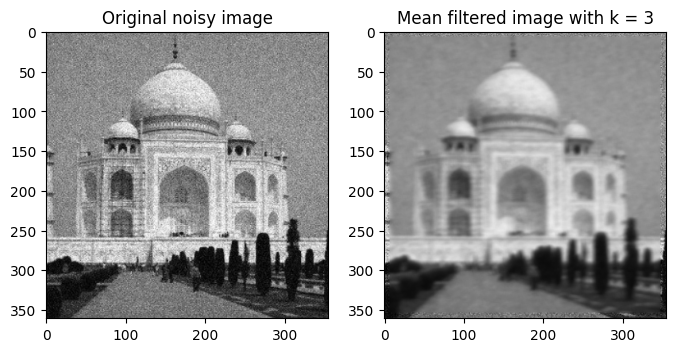

In [47]:
# display the noise-reduced image along with cross-correlated image
fig, axes = plt.subplots(1,2, figsize=(8, 8))
ax        = axes[0]
ax.imshow(img_pil_array, cmap='gray')
ax.set_title('Original noisy image')
ax        = axes[1]
ax.imshow(new_img, cmap='gray')
ax.set_title('Mean filtered image with k = ' + str(k))

new_img.save('tajmahal_mean_filter_k_' + str(k) + '.png')

#**Group activity#5: cross-correlation with different kernel sizes**
> Apply cross-correlation with different kernel sizes and observe how this affects the noisy 'Taj Mahal' image.

In [ ]:
# Your code here
# ...
# ...